In [ ]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtTiny, InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

I0000 00:00:1777572151.014534    5975 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777572151.208812    5975 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777572152.120265    5975 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# Path to your single dataset folder (should have subfolders for each class)
data_dir = '/teamspace/studios/this_studio/Bottle_Gourd'  # e.g., 'vegetable_dataset/'

# Parameters
BATCH_SIZE = 32
IMG_SIZE = (224, 224)  # DenseNet121 default input size
NUM_CLASSES = 8
EPOCHS = 1
VAL_SPLIT = 0.2  # 20% for validation
TEST_SPLIT = 0.1  # 10% for testing

In [4]:
# Step 2: Load and preprocess dataset with progress bar
def load_dataset(data_dir):
    images = []
    labels = []

    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: Directory {class_dir} not found!")
            continue

        print(f"Loading {class_name} images...")
        for img_file in tqdm(os.listdir(class_dir)):
            img_path = os.path.join(class_dir, img_file)
            try:
                with Image.open(img_path) as img:
                    img = img.convert('RGB')  # Ensure RGB format
                    img = img.resize(IMAGE_SIZE)
                    img_array = np.array(img) / 255.0
                    if img_array.shape == (*IMAGE_SIZE, 3):
                        images.append(img_array)
                        labels.append(class_idx)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return np.array(images), np.array(labels)

In [5]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from collections import Counter
from tensorflow.keras.preprocessing.image import img_to_array, load_img, ImageDataGenerator

IMG_SIZE = (224, 224)
TARGET_PER_CLASS = 1000  # 3x from 500 original images

# 🏷 Class names
class_names = sorted(os.listdir(data_dir))
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

# 🎛 Data Augmentation Setup
aug_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# 🖼 Load images and apply augmentation
all_images = []
all_labels = []

for class_idx, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    img_names = os.listdir(class_path)
    img_paths = [os.path.join(class_path, img) for img in img_names]

    # Load original images
    original_images = []
    for img_path in img_paths:
        img = load_img(img_path, target_size=IMG_SIZE)
        img_array = img_to_array(img)
        img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
        original_images.append(img_array)

    # Add original images
    all_images.extend(original_images)
    all_labels.extend([class_idx] * len(original_images))

    # Number of augmented images to generate
    num_to_generate = TARGET_PER_CLASS - len(original_images)
    print(f"{class_name}: Generating {num_to_generate} augmented images")

    i = 0
    while i < num_to_generate:
        img = random.choice(original_images)
        img = np.expand_dims(img, axis=0)
        for batch in aug_gen.flow(img, batch_size=1):
            all_images.append(batch[0])
            all_labels.append(class_idx)
            i += 1
            if i >= num_to_generate:
                break

# 🔀 Final dataset
X = np.array(all_images)
y = np.array(all_labels)
print(f"\n✅ Total images after augmentation: {X.shape[0]}")
print("Class distribution:", Counter(y))

# 🔀 Split: 15% test, then 15% val, rest train
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

# 📦 TF Datasets
def create_dataset(X, y):
    return tf.data.Dataset.from_tensor_slices((X, tf.one_hot(y, depth=NUM_CLASSES)))

train_ds = create_dataset(X_train, y_train).shuffle(1000).batch(BATCH_SIZE)
val_ds = create_dataset(X_val, y_val).batch(BATCH_SIZE)
test_ds = create_dataset(X_test, y_test).batch(BATCH_SIZE)

# 🧾 Summary
print("\n✅ Final dataset shapes:")
print("Train:", X_train.shape, " | ", Counter(y_train))
print("Val  :", X_val.shape, " | ", Counter(y_val))
print("Test :", X_test.shape, " | ", Counter(y_test))

Classes: ['Alternaria_Leaf_Blight', 'Angular_Leaf_spot', 'Anthracnose', 'Downy_Mildew', 'Early_Alternaria_Leaf_Blight', 'Fungal_Damage_Leaf', 'Healthy', 'Mosaic_Virus']


Alternaria_Leaf_Blight: Generating 821 augmented images
Angular_Leaf_spot: Generating 986 augmented images
Anthracnose: Generating 502 augmented images
Downy_Mildew: Generating 954 augmented images
Early_Alternaria_Leaf_Blight: Generating 955 augmented images
Fungal_Damage_Leaf: Generating 969 augmented images
Healthy: Generating 945 augmented images
Mosaic_Virus: Generating 749 augmented images

✅ Total images after augmentation: 8000
Class distribution: Counter({0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000})


W0000 00:00:1777572218.234225    5975 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



✅ Final dataset shapes:
Train: (5599, 224, 224, 3)  |  Counter({5: 700, 7: 700, 4: 700, 1: 700, 2: 700, 3: 700, 0: 700, 6: 699})
Val  : (1201, 224, 224, 3)  |  Counter({6: 151, 1: 150, 7: 150, 0: 150, 5: 150, 4: 150, 3: 150, 2: 150})
Test : (1200, 224, 224, 3)  |  Counter({7: 150, 5: 150, 0: 150, 2: 150, 1: 150, 3: 150, 4: 150, 6: 150})


In [ ]:
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtTiny, InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, Average, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Constants
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 8  # Adjust according to your dataset

def create_individual_model(base_model_class, dropout_rate=0.2):
    """Helper function to create individual models with consistent architecture"""
    base_model = base_model_class(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE)
    base_model.trainable = True
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)
    
    return Model(inputs=base_model.input, outputs=predictions)

def build_ensemble():
    """Build the ensemble model combining all three models"""
    # Create individual models
    efficient = create_individual_model(EfficientNetV2S, dropout_rate=0.2)
    convnext = create_individual_model(ConvNeXtTiny, dropout_rate=0.2)
    inception = create_individual_model(InceptionV3, dropout_rate=0.5)
    
    # Give them identifiable names
    efficient._name = 'efficient'
    convnext._name = 'convnext'
    inception._name = 'inception'
    
    # Create separate input layers for each model
    input_efficient = Input(shape=INPUT_SHAPE, name='input_efficient')
    input_convnext = Input(shape=INPUT_SHAPE, name='input_convnext')
    input_inception = Input(shape=INPUT_SHAPE, name='input_inception')
    
    # Get individual predictions
    pred_efficient = efficient(input_efficient)
    pred_convnext = convnext(input_convnext)
    pred_inception = inception(input_inception)
    
    # Weighted average based on your validation accuracies
    weights = {
        'efficient': 0.335,    # EfficientNetV2S 99.33%
        'convnext': 0.332,     # ConvNeXtTiny 98.33%
        'inception': 0.334     # InceptionV3 98.92%
    }
    
    # Weighted predictions using Keras Lambda layer
    weighted_efficient = Lambda(lambda x: x * weights['efficient'])(pred_efficient)
    weighted_convnext = Lambda(lambda x: x * weights['convnext'])(pred_convnext)
    weighted_inception = Lambda(lambda x: x * weights['inception'])(pred_inception)
    
    weighted_avg = Average()([weighted_efficient, weighted_convnext, weighted_inception])
    
    # Create ensemble model
    ensemble_model = Model(
        inputs=[input_efficient, input_convnext, input_inception],
        outputs=weighted_avg,
        name='top3_ensemble'
    )
    
    return ensemble_model, [efficient, convnext, inception]

def compile_ensemble(ensemble_model):
    """Compile the ensemble model"""
    ensemble_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

# Create and compile the ensemble
ensemble_model, individual_models = build_ensemble()
compile_ensemble(ensemble_model)

# Print model summary
ensemble_model.summary()


Model: "top3_ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_efficient     │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_convnext      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_inception     │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 8)         │ 20,991,336 │ input_efficient[… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_5        │ (None, 8)         │ 28,217,960 │ input_convnext[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_6        │ (None, 8)         │ 22,855,976 │ input_inception[… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 8)         │          0 │ functional[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 8)         │          0 │ functional_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 8)         │          0 │ functional_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average (Average)   │ (None, 8)         │          0 │ lambda[0][0],     │
│                     │                   │            │ lambda_1[0][0],   │
│                     │                   │            │ lambda_2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 72,065,272 (274.91 MB)

 Trainable params: 71,876,968 (274.19 MB)

 Non-trainable params: 188,304 (735.56 KB)

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Adapt dataset to provide 3 identical inputs for the ensemble
def adapt_for_ensemble(ds):
    return ds.map(lambda x, y: ((x, x, x), y))

# Adapt train and val datasets
train_ds_ensemble = adapt_for_ensemble(train_ds)
val_ds_ensemble = adapt_for_ensemble(val_ds)

# Define model name
model_name = "top3_ensemble"

# Callbacks
checkpoint = ModelCheckpoint(
    f"{model_name}.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-4,
    verbose=1
)

# Compile the ensemble model (if not already compiled)
ensemble_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Train the ensemble model
history = ensemble_model.fit(
    train_ds_ensemble,
    validation_data=val_ds_ensemble,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


I0000 00:00:1777572280.274262   10790 service.cc:153] XLA service 0x740004018d30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777572280.274301   10790 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1777572280.389439   10790 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8462 - loss: 0.6111 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00
Epoch 1: val_accuracy improved from None to 0.94255, saving model to top3_ensemble.h5



Epoch 1: finished saving model to top3_ensemble.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 668s 3s/step - accuracy: 0.9148 - loss: 0.3183 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9425 - val_loss: 0.1348 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.


In [ ]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


38/38 ━━━━━━━━━━━━━━━━━━━━ 35s 823ms/step
Classification Report:

                              precision    recall  f1-score   support

      Alternaria_Leaf_Blight       0.95      0.86      0.90       150
           Angular_Leaf_spot       0.99      0.99      0.99       150
                 Anthracnose       0.68      0.95      0.79       150
                Downy_Mildew       0.99      0.97      0.98       150
Early_Alternaria_Leaf_Blight       1.00      0.95      0.98       150
          Fungal_Damage_Leaf       0.99      0.97      0.98       150
                     Healthy       0.99      0.97      0.98       150
                Mosaic_Virus       0.95      0.77      0.85       150

                    accuracy                           0.93      1200
                   macro avg       0.94      0.93      0.93      1200
                weighted avg       0.94      0.93      0.93      1200


Confusion matrix, without normalization


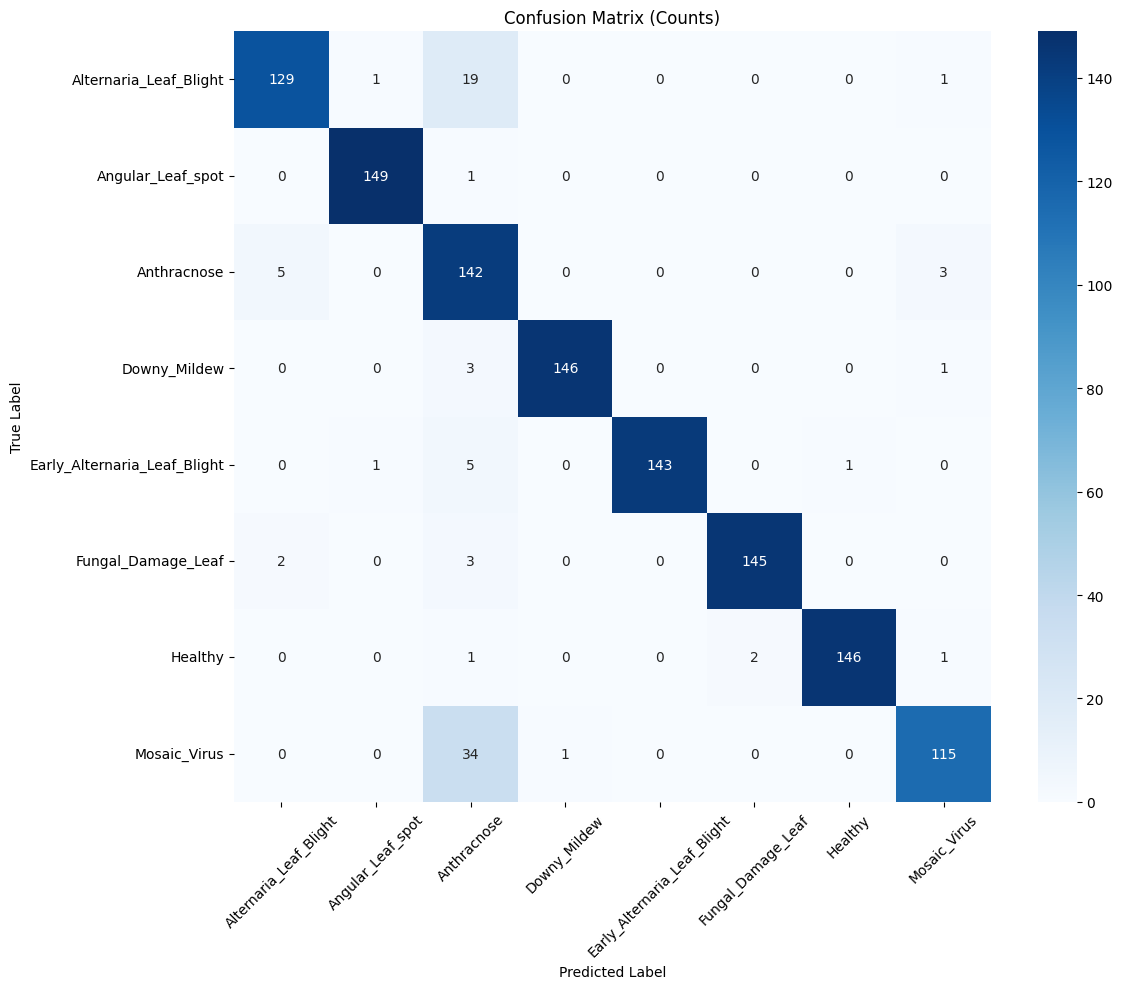


Normalized confusion matrix


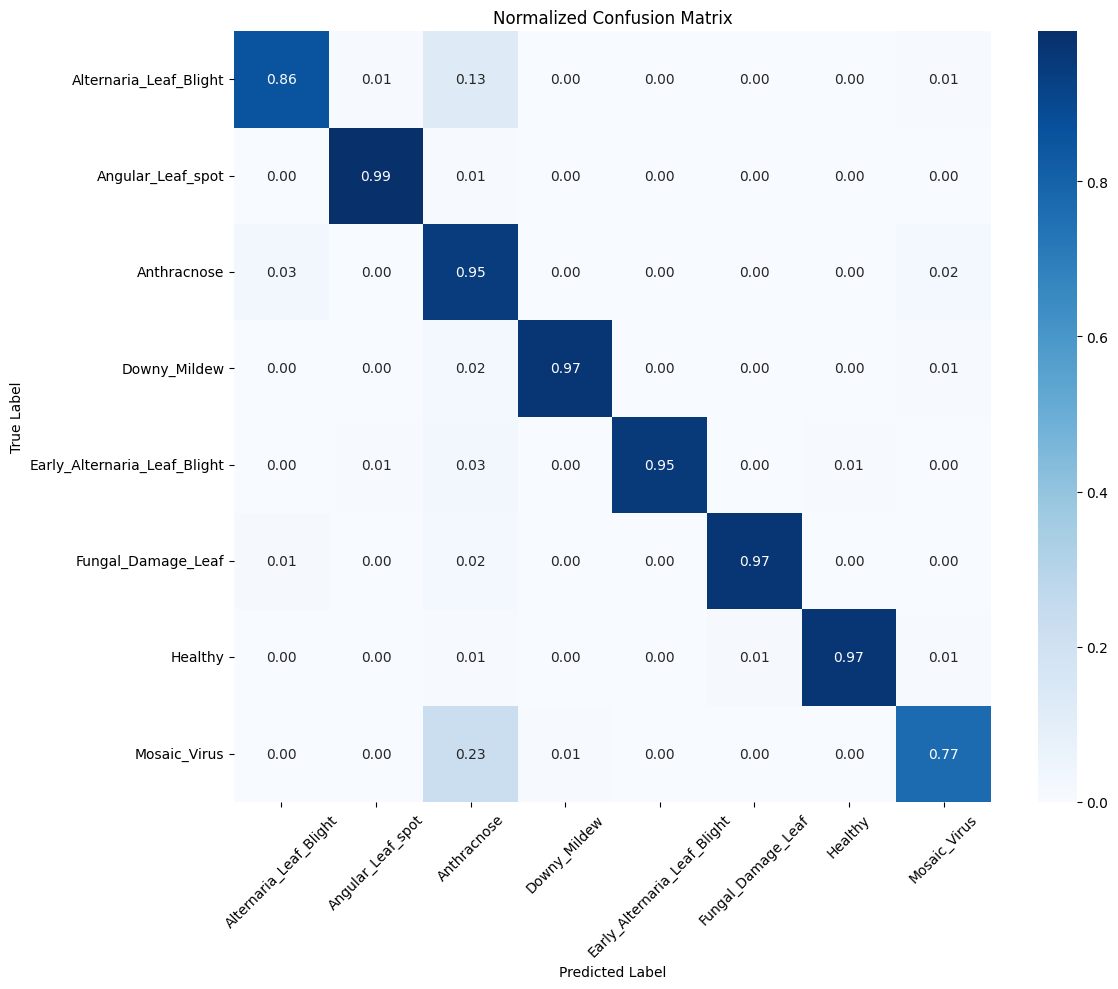

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ✅ Ensemble expects 3 inputs, so we must pass (x, x, x)
def prepare_test_for_prediction(ds):
    return ds.map(lambda x, y: ((x, x, x), y))

# 🧪 Prepare test dataset for prediction
test_ds_ens = prepare_test_for_prediction(test_ds)

# 🔍 Predict
y_pred_probs = ensemble_model.predict(test_ds_ens)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 🎯 Extract true labels
y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

# 🧾 Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# 📊 Confusion matrix plotting function
def plot_confusion_matrix(y_true, y_pred, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        print("\nNormalized confusion matrix")
    else:
        print("\nConfusion matrix, without normalization")

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd',
                cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 🖼️ Plot both confusion matrices
plot_confusion_matrix(y_true, y_pred_classes, classes=class_names, title='Confusion Matrix (Counts)')
plot_confusion_matrix(y_true, y_pred_classes, classes=class_names, normalize=True, title='Normalized Confusion Matrix')


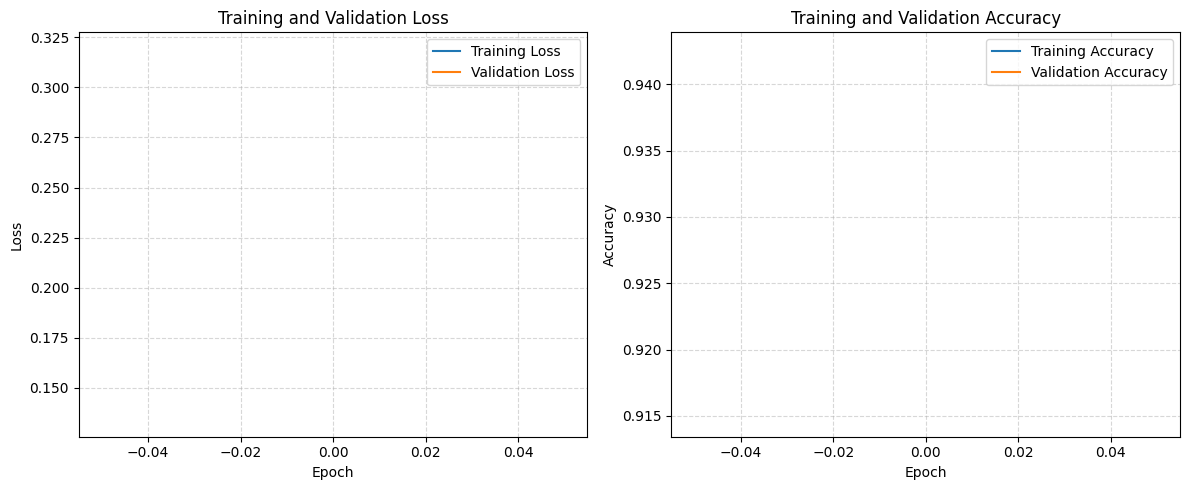


📉 Best Validation Loss: 0.1348 at epoch 1
   Training Loss at that epoch: 0.3183
   Validation Accuracy at that epoch: 0.9425


In [ ]:
import matplotlib.pyplot as plt
import numpy as np  # Ensure numpy is imported

# ✅ Make sure to pass the correct 'history' object from model.fit()
# Example: history = train_ensemble(ensemble_model, train_ds, val_ds, epochs=...)
history_dict = history.history

# 📊 Create figure with two subplots
plt.figure(figsize=(12, 5))

# 1️⃣ Plot Loss Curves
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2️⃣ Plot Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 🏆 Optional: Print best validation loss & related info
best_val_epoch = np.argmin(history_dict['val_loss'])
print(f"\n📉 Best Validation Loss: {history_dict['val_loss'][best_val_epoch]:.4f} at epoch {best_val_epoch + 1}")
print(f"   Training Loss at that epoch: {history_dict['loss'][best_val_epoch]:.4f}")
print(f"   Validation Accuracy at that epoch: {history_dict['val_accuracy'][best_val_epoch]:.4f}")


 8/38 ━━━━━━━━━━━━━━━━━━━━ 22s 738ms/step

38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 723ms/step


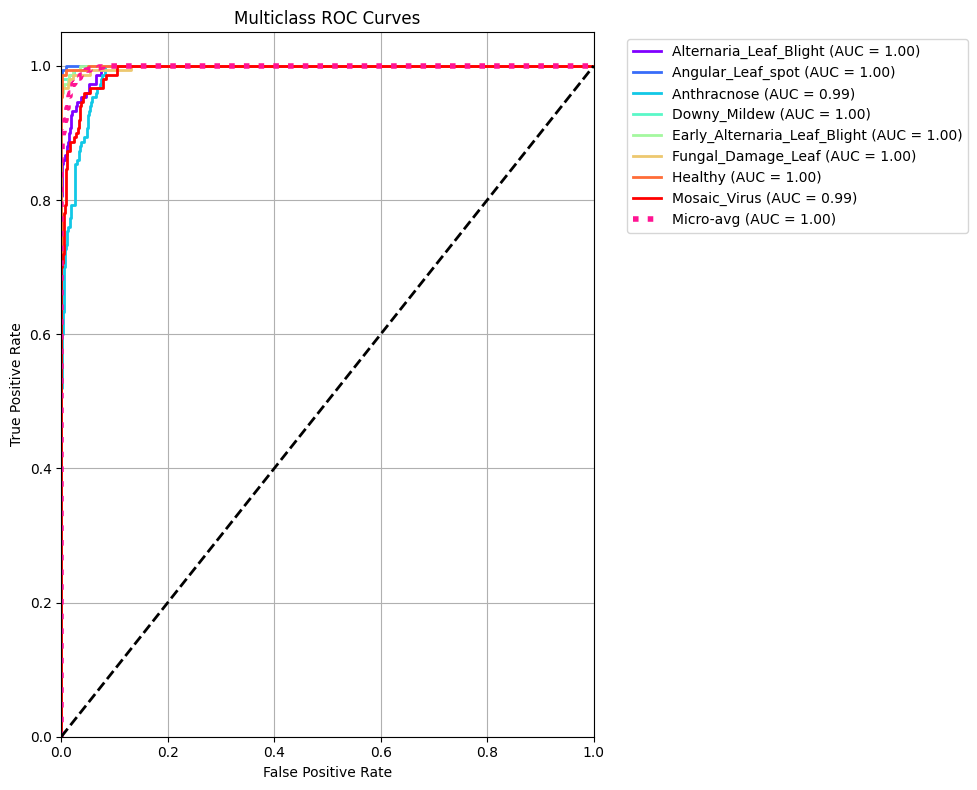


📊 AUC Scores:
Alternaria_Leaf_Blight: 0.9953
Angular_Leaf_spot: 0.9999
Anthracnose: 0.9888
Downy_Mildew: 0.9994
Early_Alternaria_Leaf_Blight: 0.9994
Fungal_Damage_Leaf: 0.9984
Healthy: 0.9996
Mosaic_Virus: 0.9928

Micro-average AUC: 0.9979


In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np

# ✅ Step 1: Prepare test dataset for ensemble model (x, x, x)
def prepare_test_for_prediction(ds):
    return ds.map(lambda x, y: ((x, x, x), y))

test_ds_ens = prepare_test_for_prediction(test_ds)

# ✅ Step 2: Get predictions from model
y_pred = ensemble_model.predict(test_ds_ens)

# ✅ Step 3: Get true labels from one-hot encoded test set
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)  # Convert one-hot to labels

# ✅ Step 4: Binarize the true labels for ROC
y_true_bin = label_binarize(y_true_labels, classes=np.arange(NUM_CLASSES))

# ✅ Step 5: Compute ROC curves and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ✅ Step 6: Compute micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# ✅ Step 7: Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(plt.cm.rainbow(np.linspace(0, 1, NUM_CLASSES)))

for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:0.2f})')

# Micro-average curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-avg (AUC = {roc_auc["micro"]:0.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Final plot settings
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Step 8: Print AUC scores
print("\n📊 AUC Scores:")
for i in range(NUM_CLASSES):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")
print(f"\nMicro-average AUC: {roc_auc['micro']:.4f}")


 9/38 ━━━━━━━━━━━━━━━━━━━━ 21s 729ms/step

38/38 ━━━━━━━━━━━━━━━━━━━━ 27s 720ms/step


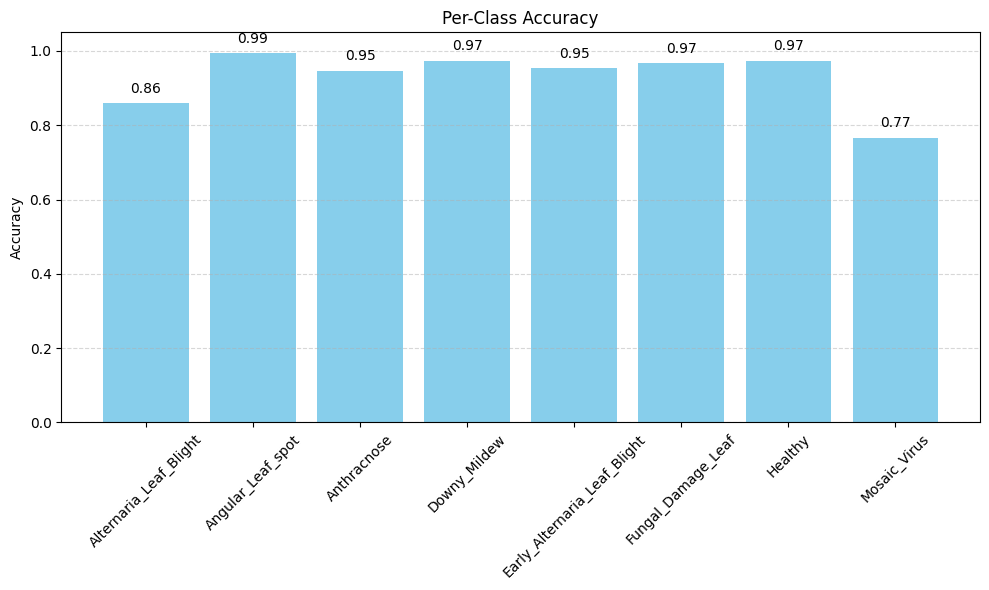

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from collections import defaultdict

# ✅ Step 1: Prepare test data for ensemble
def prepare_test_for_prediction(ds):
    return ds.map(lambda x, y: ((x, x, x), y))

test_ds_ens = prepare_test_for_prediction(test_ds)

# ✅ Step 2: Get model predictions
y_pred_probs = ensemble_model.predict(test_ds_ens)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Step 3: Extract true labels
y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

# ✅ Step 4: Compute per-class accuracy
class_correct = defaultdict(int)
class_total = defaultdict(int)

for true, pred in zip(y_true, y_pred):
    class_total[true] += 1
    if true == pred:
        class_correct[true] += 1

per_class_acc = {
    class_names[i]: class_correct[i] / class_total[i]
    for i in range(NUM_CLASSES)
}

# ✅ Step 5: Plot bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(per_class_acc.keys(), per_class_acc.values(), color='skyblue')
plt.ylim([0, 1.05])
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
!pip install umap-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 86.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 231.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [numba]


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


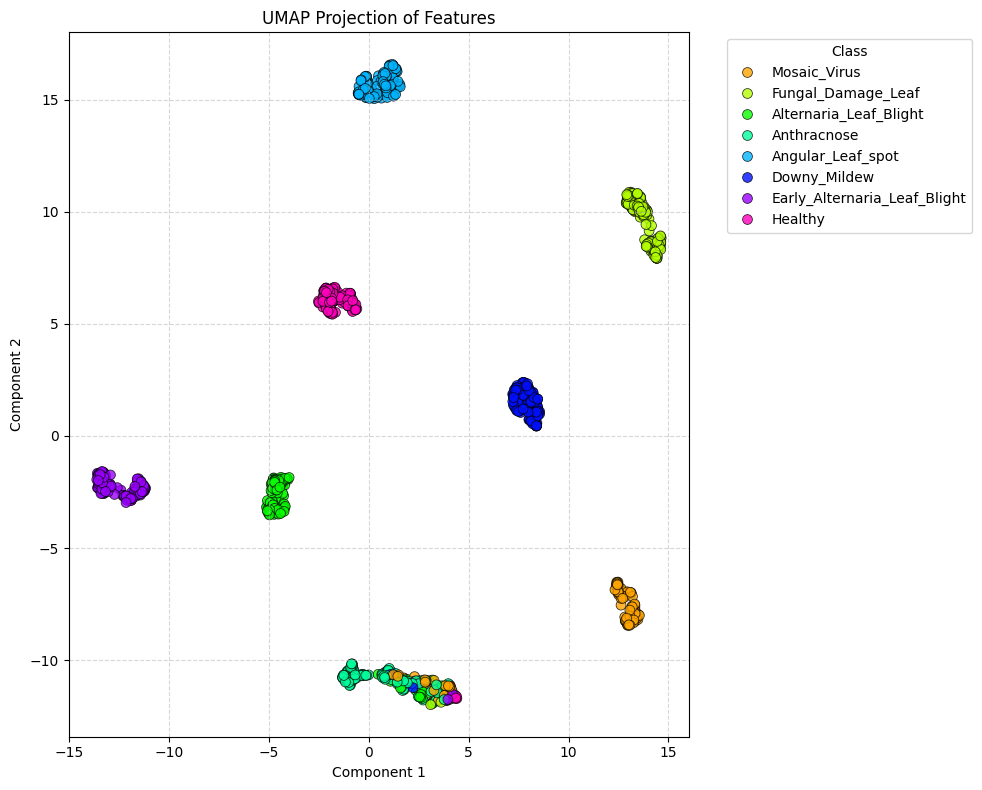

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import LabelEncoder

# ✅ Extract features from penultimate layer of individual models
# We'll use NASNet as example; you can do same for others
feature_extractor = tf.keras.Model(
    inputs=individual_models[0].input,  # NASNet
    outputs=individual_models[0].layers[-3].output  # Just before final Dense(softmax)
)

# ✅ Prepare feature extraction dataset
def extract_features_and_labels(ds, model):
    features = []
    labels = []
    for batch_x, batch_y in ds:
        # Only take first input (x), since we trained all models with same input
        batch_feats = model.predict(batch_x, verbose=0)
        features.append(batch_feats)
        labels.extend(np.argmax(batch_y.numpy(), axis=1))
    return np.concatenate(features), np.array(labels)

# ✅ Use original test_ds (not ensemble-wrapped)
features, labels = extract_features_and_labels(test_ds, feature_extractor)

# Choose between UMAP and t-SNE
use_umap = True  # 🔄 Switch to False to use t-SNE instead

if use_umap:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    reduced = reducer.fit_transform(features)
    title = "UMAP Projection of Features"
else:
    reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced = reducer.fit_transform(features)
    title = "t-SNE Projection of Features"

# ✅ Plot embeddings
plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", NUM_CLASSES)
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=[class_names[i] for i in labels],
                palette=palette, s=50, alpha=0.8, edgecolor='k')

plt.title(title)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), title="Class")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


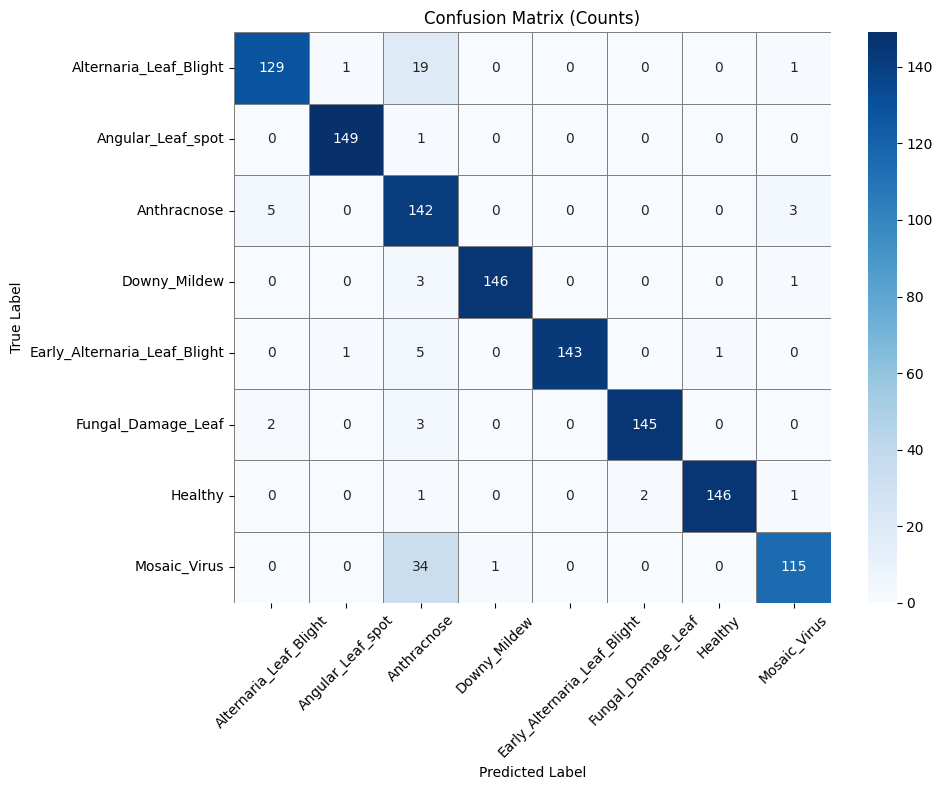

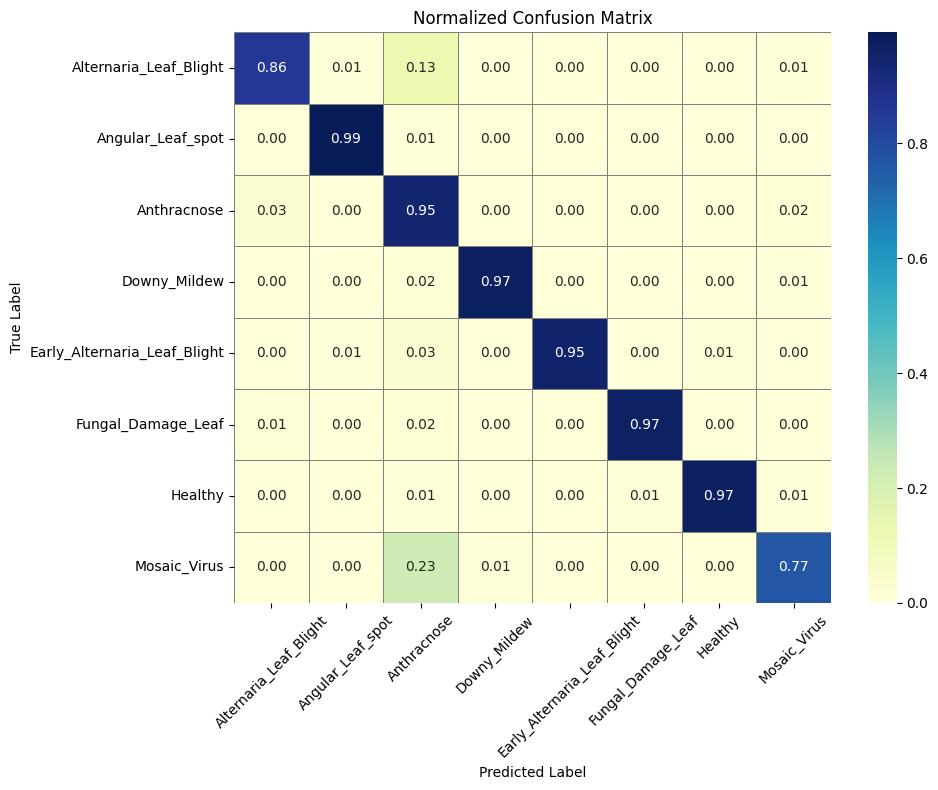

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_and_save_confusion_heatmap(y_true, y_pred, class_names, normalize=False,
                                     title="Confusion Matrix Heatmap", filename="confusion_heatmap.png"):
    """
    Plot and save a confusion matrix heatmap.

    Args:
        y_true: Array of ground truth labels
        y_pred: Array of predicted labels
        class_names: List of class names
        normalize: If True, normalize the matrix
        title: Title of the plot
        filename: Output filename to save the image
    """
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = ".2f"
        cmap = "YlGnBu"
    else:
        fmt = "d"
        cmap = "Blues"

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names,
                yticklabels=class_names,
                linewidths=0.5, linecolor='gray')

    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # ✅ Save heatmap as image
    plt.savefig(filename, dpi=300)
    plt.show()

# ✅ Example usage
plot_and_save_confusion_heatmap(
    y_true=y_true,
    y_pred=y_pred_classes,
    class_names=class_names,
    normalize=False,
    title="Confusion Matrix (Counts)",
    filename="confusion_matrix_counts.png"
)

plot_and_save_confusion_heatmap(
    y_true=y_true,
    y_pred=y_pred_classes,
    class_names=class_names,
    normalize=True,
    title="Normalized Confusion Matrix",
    filename="confusion_matrix_normalized.png"
)


19/38 ━━━━━━━━━━━━━━━━━━━━ 13s 732ms/step

38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 725ms/step


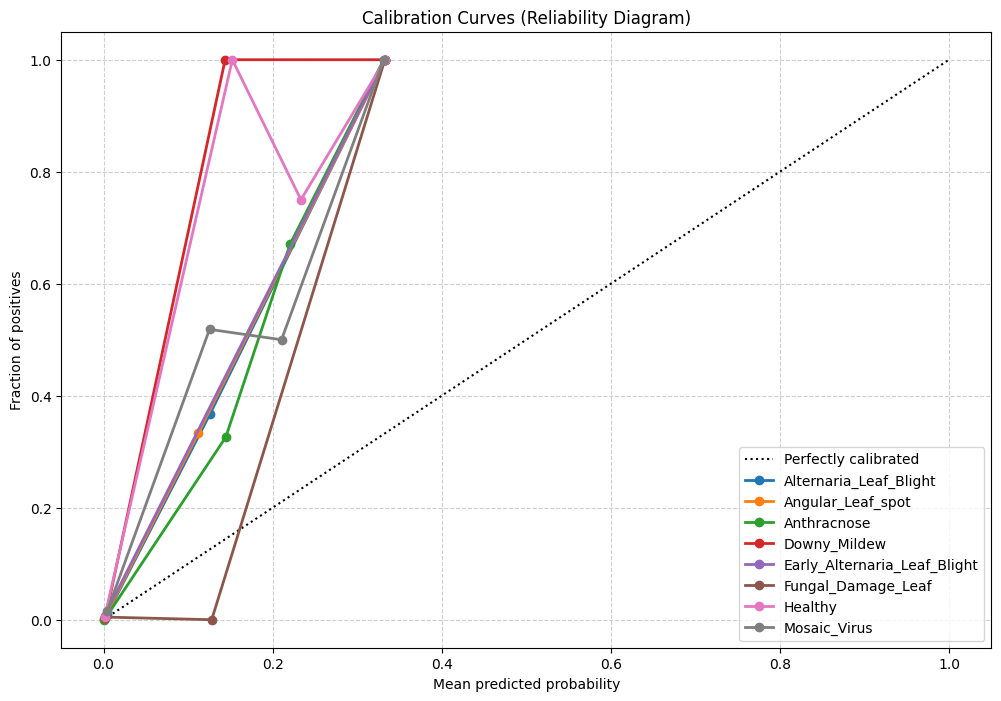

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

def plot_multiclass_calibration_curve(model, test_ds, class_names, num_bins=10):
    """
    Plot calibration curves for each class.

    Args:
        model: Trained Keras model (ensemble_model)
        test_ds: tf.data.Dataset yielding ((x1,x2,x3), y) tuples with one-hot labels
        class_names: list of class names
        num_bins: number of bins for calibration curve
    """

    # Prepare test data inputs for ensemble (x,x,x)
    def prepare_ensemble(ds):
        return ds.map(lambda x, y: ((x, x, x), y))
    test_ds_ens = prepare_ensemble(test_ds)

    # Get predicted probabilities and true labels
    y_pred_probs = model.predict(test_ds_ens)
    y_true_onehot = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

    n_classes = len(class_names)

    plt.figure(figsize=(12, 8))
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_true_onehot[:, i], y_pred_probs[:, i], n_bins=num_bins)
        plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=f"{class_names[i]}")

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration Curves (Reliability Diagram)")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Example call:
plot_multiclass_calibration_curve(ensemble_model, test_ds, class_names, num_bins=10)


In [22]:
!pip install opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 204.9 MB/s  0:00:00 eta 0:00:01


In [23]:
!pip install opencv-python

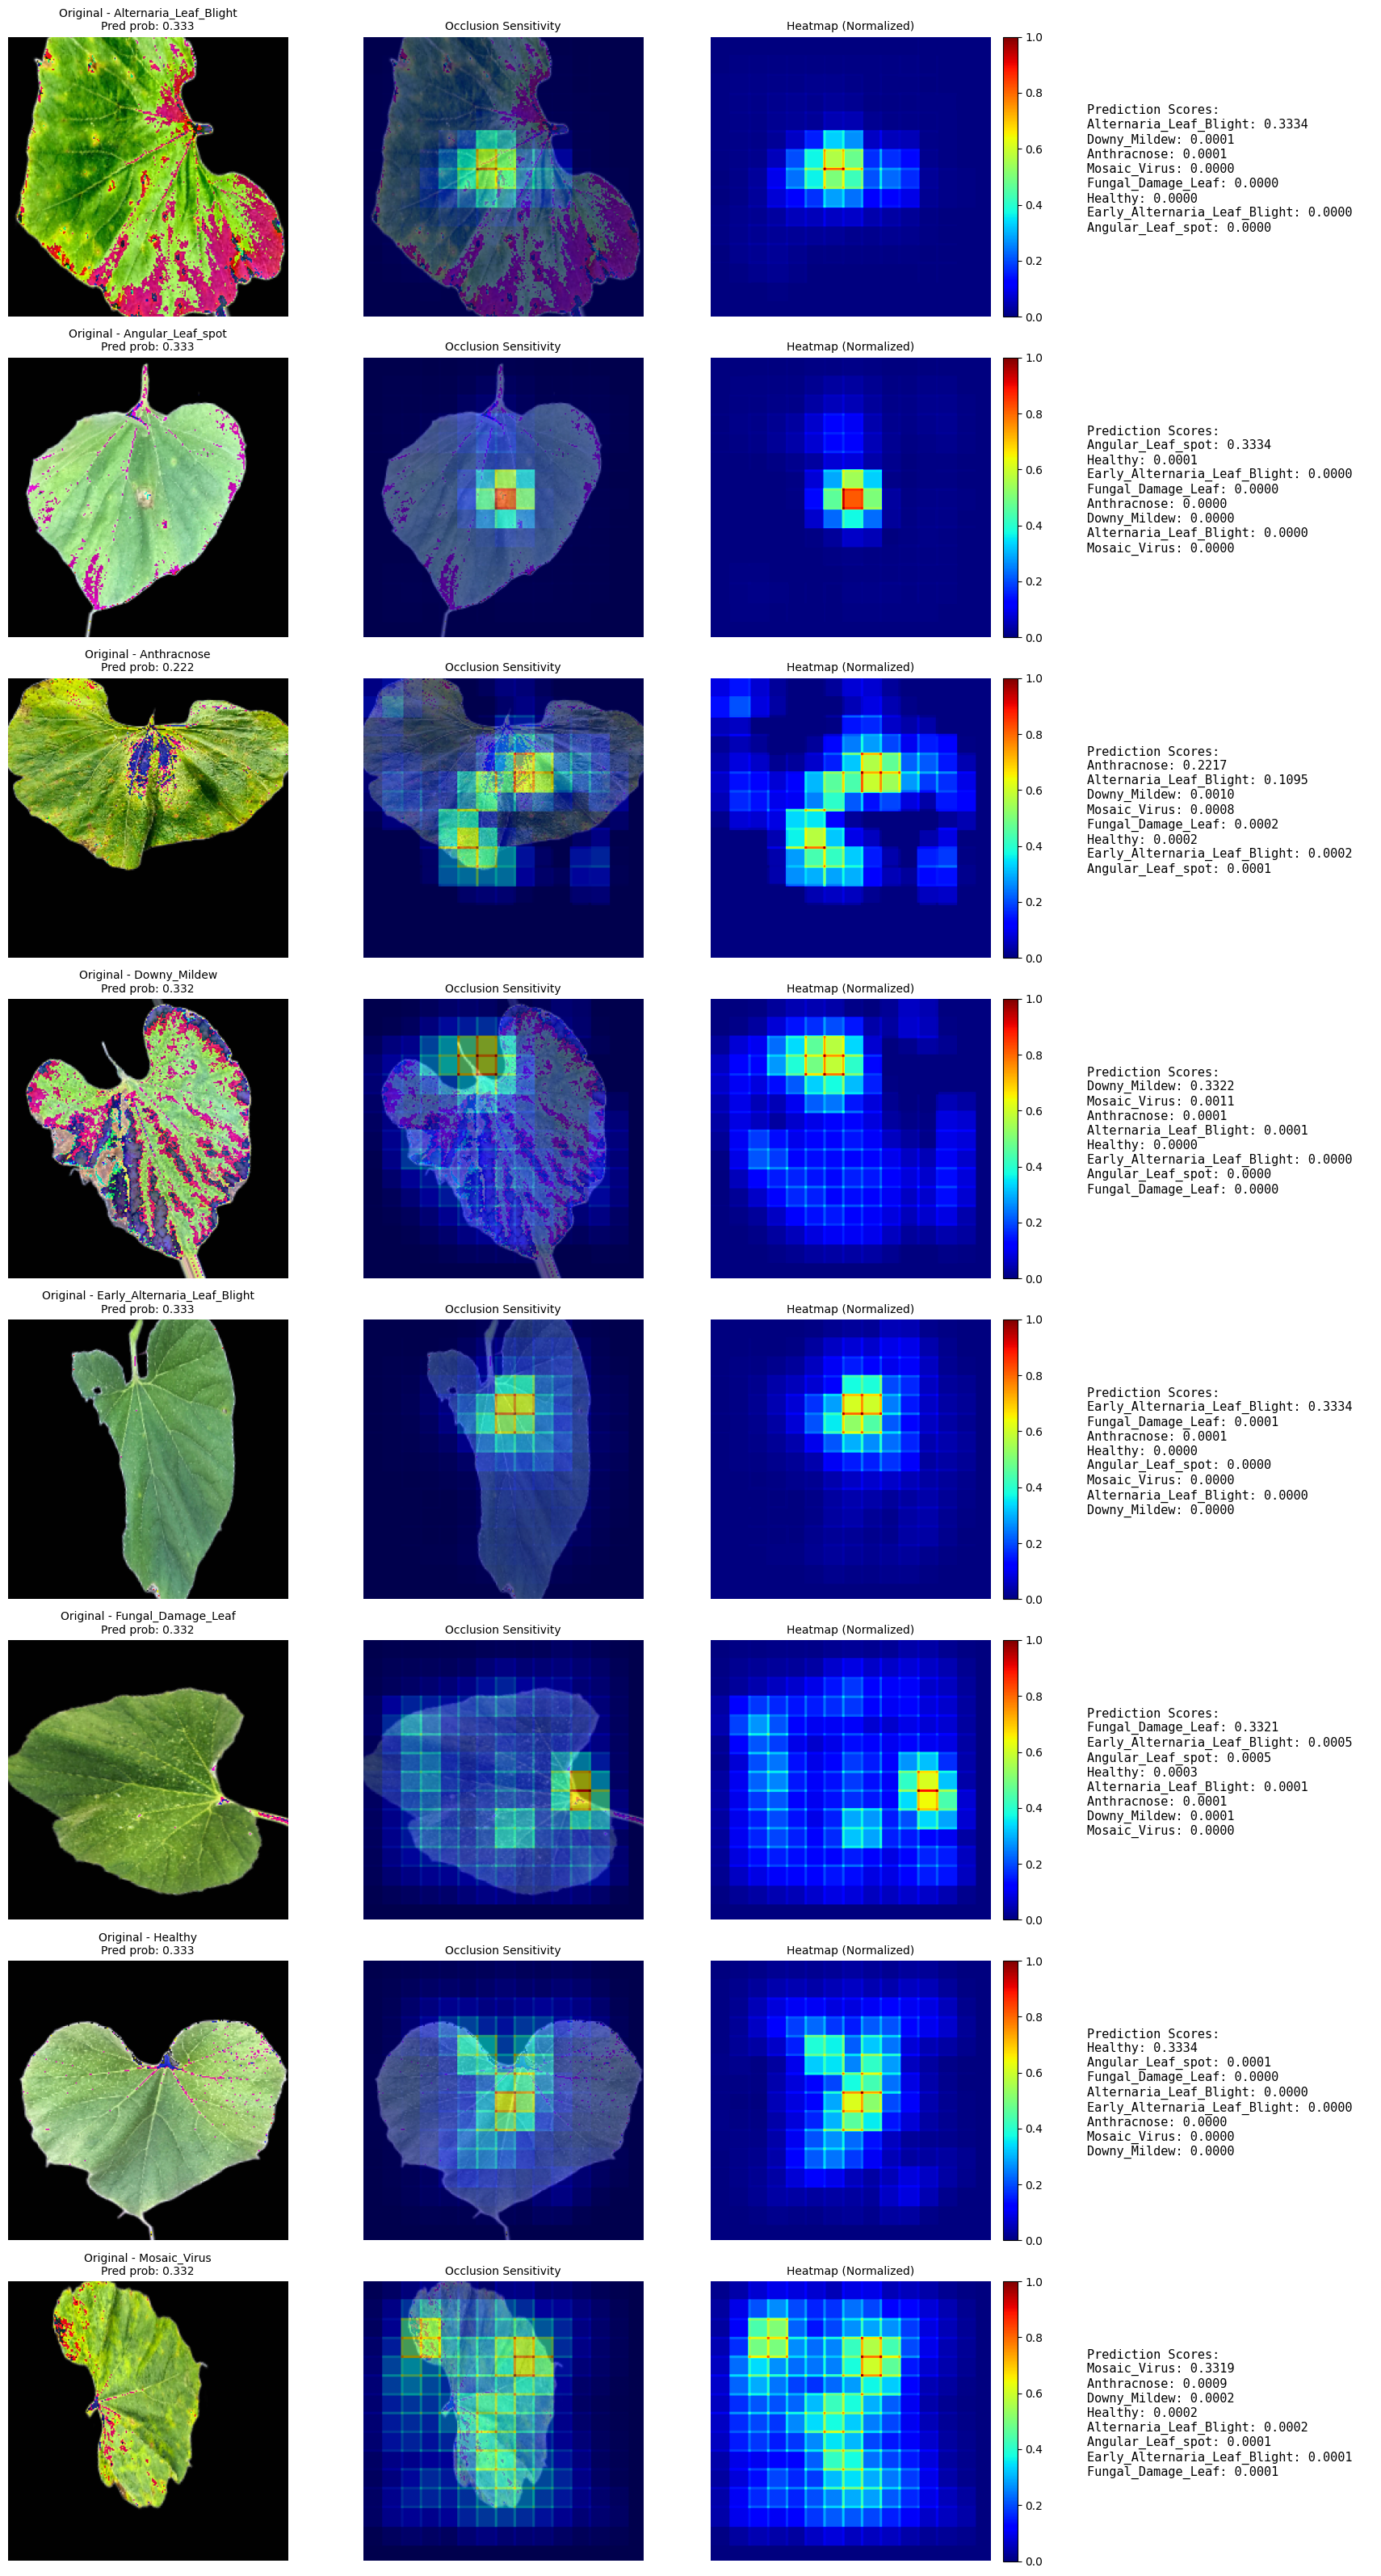

In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

# --- ১. এনসেম্বল প্রেডিকশন ফাংশন ---
def get_ensemble_predict(image_batch, model):
    # ইনপুট ছবিকে ৩টি হেডের জন্য ৩বার পাঠানো
    preds = model.predict([image_batch, image_batch, image_batch], verbose=0)
    return preds

# --- ২. Occlusion Sensitivity কোর ফাংশন ---
def compute_occlusion_heatmap(model, img, class_idx, patch_size=32, stride=15):
    height, width, _ = img.shape
    heatmap = np.zeros((height, width))
    img_input = np.expand_dims(img, axis=0)
    original_preds = get_ensemble_predict(img_input, model)
    original_score = original_preds[0][class_idx]
    
    for y in range(0, height - patch_size + 1, stride):
        for x in range(0, width - patch_size + 1, stride):
            img_masked = img.copy()
            img_masked[y:y+patch_size, x:x+patch_size, :] = 0 
            masked_input = np.expand_dims(img_masked, axis=0)
            preds = get_ensemble_predict(masked_input, model)
            score_after_occlusion = preds[0][class_idx]
            heatmap[y:y+patch_size, x:x+patch_size] += (original_score - score_after_occlusion)
            
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)
    return heatmap

# --- ৩. ভিজ্যুয়ালাইজেশন ফাংশন (ফিক্সড লেবেল হ্যান্ডেলিং) ---
def plot_occlusion_results(model, test_images, test_labels, class_names):
    num_classes = len(class_names)
    fig, axes = plt.subplots(num_classes, 4, figsize=(18, num_classes * 4))
    
    # লেবেল যদি One-Hot হয় তবে তাকে ইন্টিজারে রূপান্তর
    if len(test_labels.shape) > 1:
        test_labels_int = np.argmax(test_labels, axis=1)
    else:
        test_labels_int = test_labels

    for i in range(num_classes):
        # ওই নির্দিষ্ট ক্লাসের ছবি খুঁজে বের করা
        indices = np.where(test_labels_int == i)[0]
        if len(indices) == 0:
            print(f"⚠️ Warning: No samples found for class: {class_names[i]}")
            continue
            
        idx = indices[0]
        img = test_images[idx]
        
        # প্রেডিকশন বের করা
        img_batch = np.expand_dims(img, axis=0)
        preds = get_ensemble_predict(img_batch, model)[0]
        
        # হিটম্যাপ তৈরি
        heatmap = compute_occlusion_heatmap(model, img, i)
        
        # কলাম ১: Original Image
        display_img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
        axes[i, 0].imshow(display_img)
        axes[i, 0].set_title(f"Original - {class_names[i]}\nPred prob: {preds[i]:.3f}", fontsize=10)
        axes[i, 0].axis('off')
        
        # কলাম ২: Occlusion Overlay
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        alpha = 0.6
        overlay = cv2.addWeighted(display_img, 1-alpha, heatmap_color, alpha, 0)
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title("Occlusion Sensitivity", fontsize=10)
        axes[i, 1].axis('off')
        
        # কলাম ৩: Heatmap
        im = axes[i, 2].imshow(heatmap_resized, cmap='jet')
        axes[i, 2].set_title("Heatmap (Normalized)", fontsize=10)
        axes[i, 2].axis('off')
        fig.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)
        
        # কলাম ৪: Scores
        score_text = "Prediction Scores:\n"
        top_indices = preds.argsort()[-8:][::-1]
        for idx_cls in top_indices:
            score_text += f"{class_names[idx_cls]}: {preds[idx_cls]:.4f}\n"
        axes[i, 3].text(0.1, 0.5, score_text, verticalalignment='center', fontsize=11, family='monospace')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.savefig('Occlusion_Visualization_Final.png', dpi=300)
    plt.show()

# --- ৪. কমান্ড রান করুন ---
plot_occlusion_results(ensemble_model, X_test, y_test, class_names)

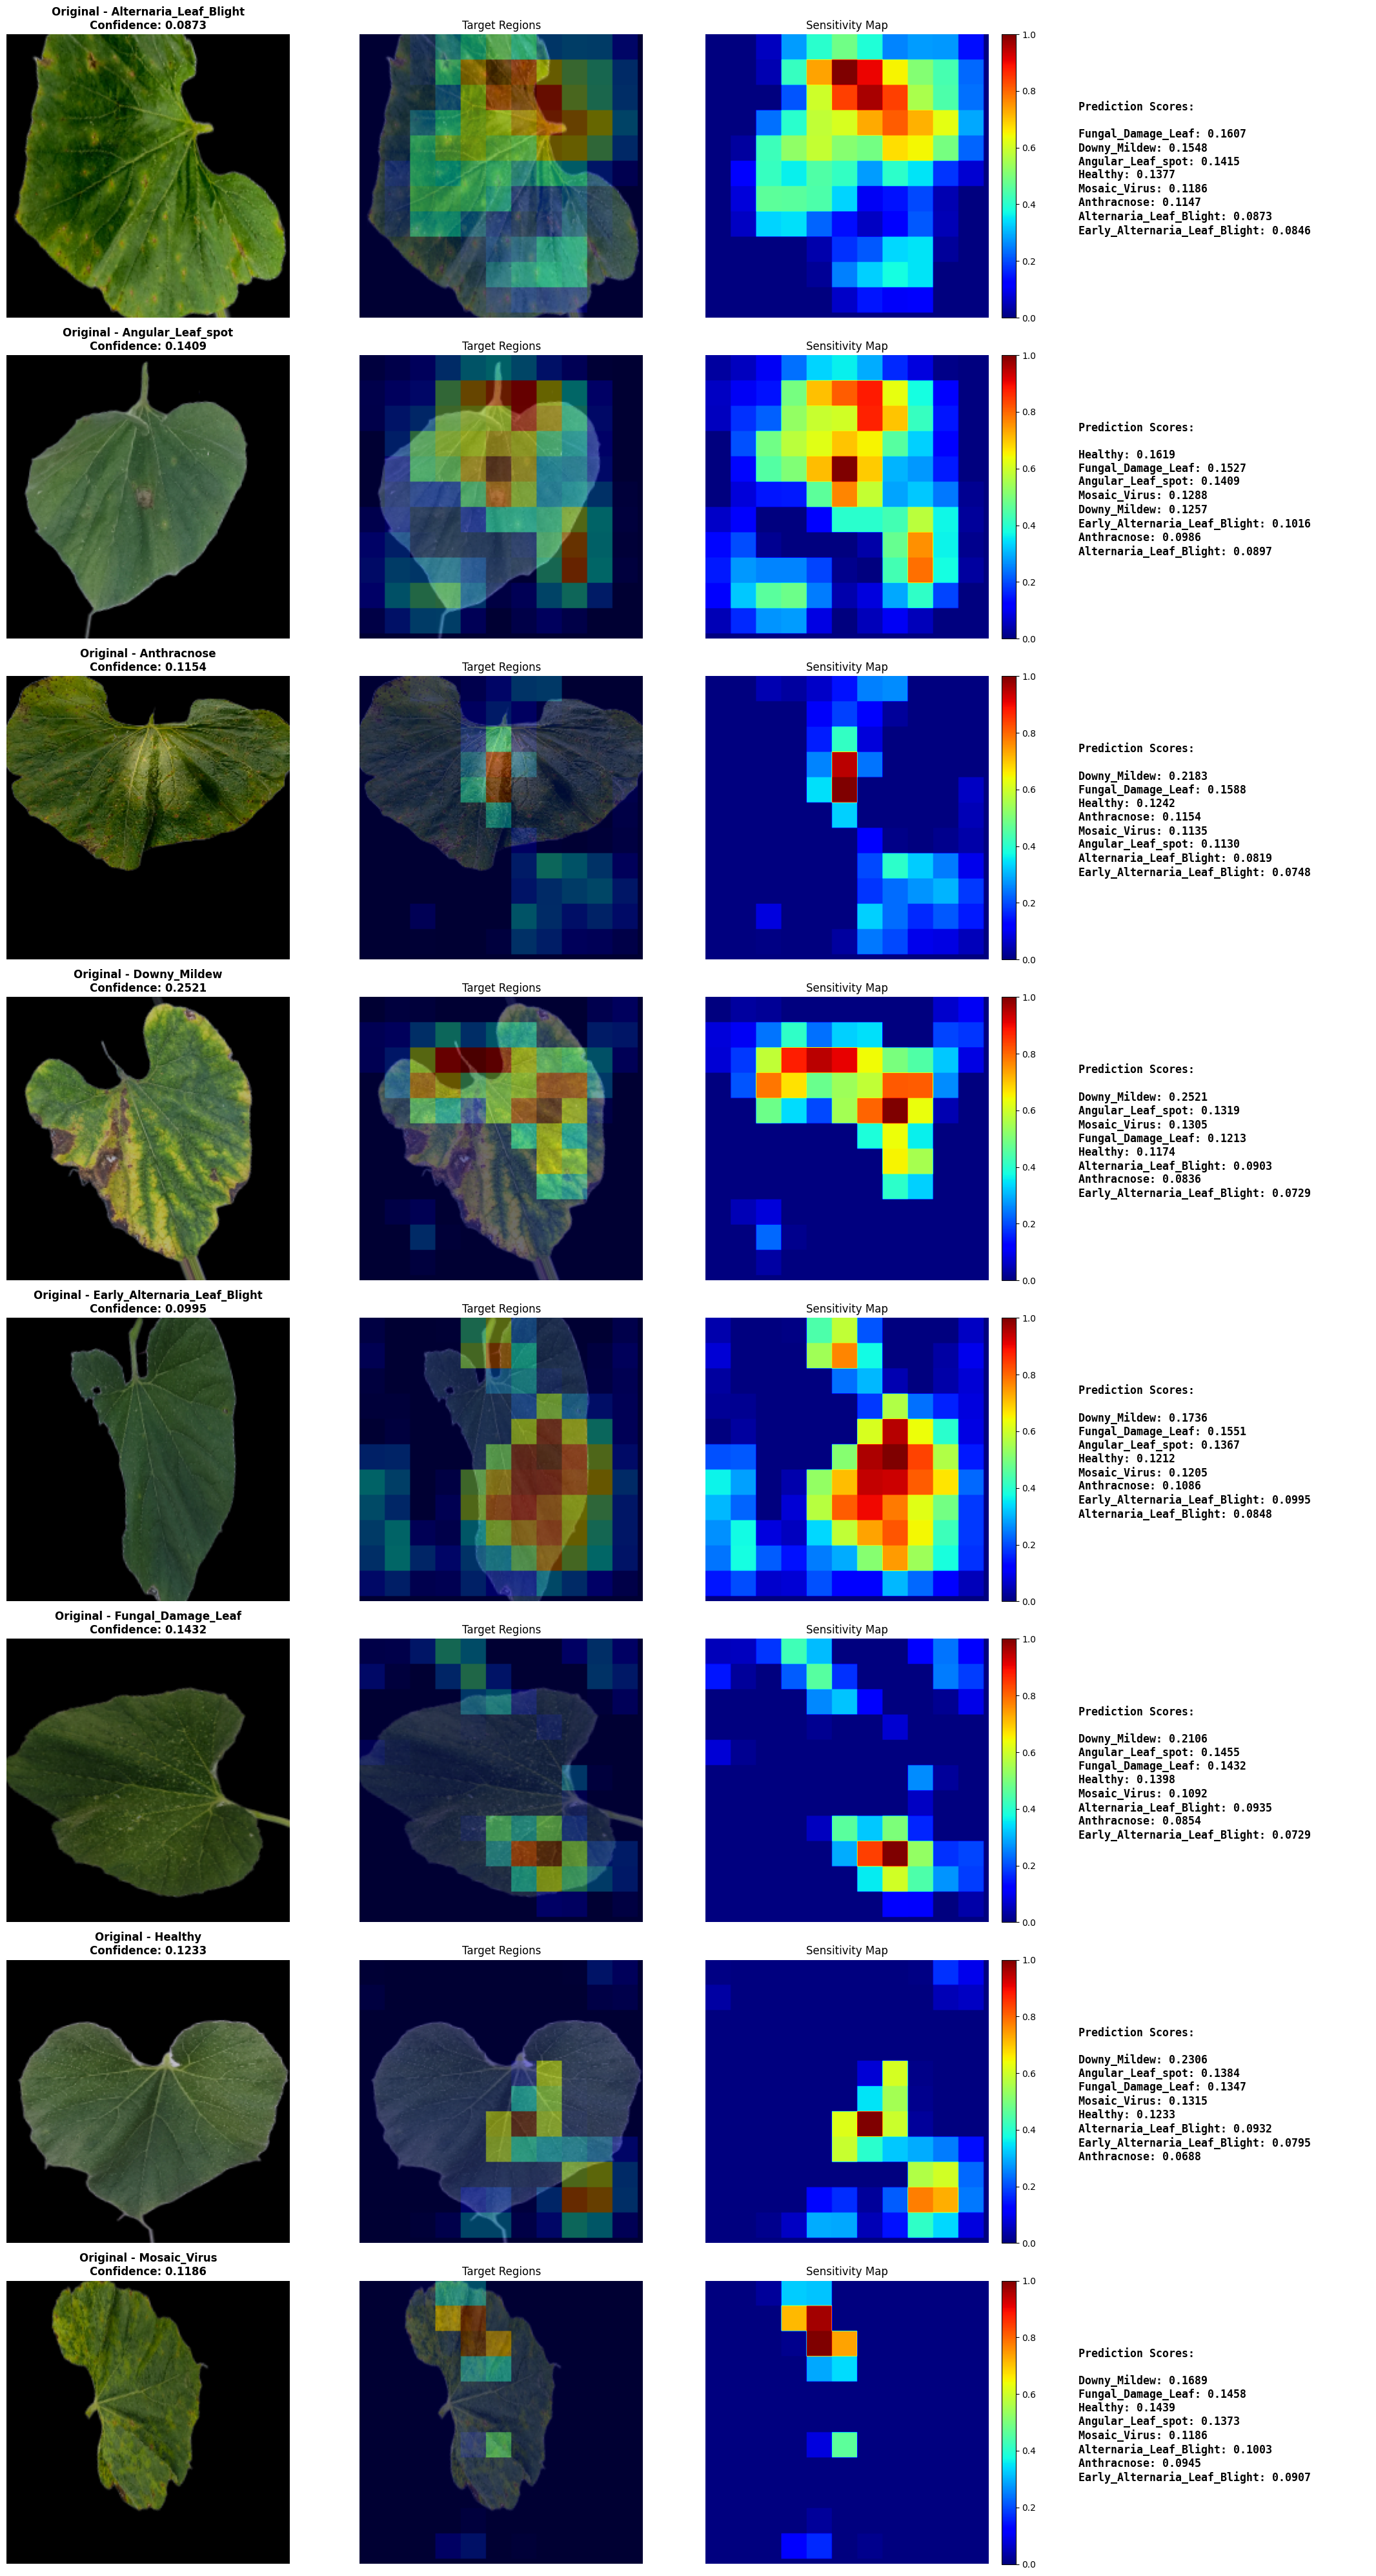

In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_ensemble_predict(image_batch, model):
    # ৩টি ইনপুটের জন্য ডাটা রিপিট
    return model.predict([image_batch, image_batch, image_batch], verbose=0)

def compute_occlusion_heatmap(model, img, class_idx, patch_size=40, stride=20):
    height, width, _ = img.shape
    heatmap = np.zeros((height, width))
    img_input = np.expand_dims(img, axis=0)
    original_score = get_ensemble_predict(img_input, model)[0][class_idx]
    
    for y in range(0, height - patch_size + 1, stride):
        for x in range(0, width - patch_size + 1, stride):
            img_masked = img.copy()
            img_masked[y:y+patch_size, x:x+patch_size, :] = 0 
            score_after = get_ensemble_predict(np.expand_dims(img_masked, axis=0), model)[0][class_idx]
            heatmap[y:y+patch_size, x:x+patch_size] += (original_score - score_after)
            
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0: heatmap /= np.max(heatmap)
    return heatmap

def plot_final_visuals(model, test_images, test_labels, class_names):
    num_classes = len(class_names)
    fig, axes = plt.subplots(num_classes, 4, figsize=(22, num_classes * 5))
    
    labels_int = np.argmax(test_labels, axis=1) if len(test_labels.shape) > 1 else test_labels

    for i in range(num_classes):
        idx = np.where(labels_int == i)[0][0]
        img = test_images[idx]
        
        # প্রেডিকশন এবং হিটম্যাপ
        preds = get_ensemble_predict(np.expand_dims(img, axis=0), model)[0]
        heatmap = compute_occlusion_heatmap(model, img, i)
        
        # ✅ কালার ফিক্স: গোলাপি ভাব দূর করা
        display_img = img.copy()
        if display_img.min() < 0: # যদি MobileNet স্টাইল -১ থেকে ১ এ থাকে
            display_img = (display_img + 1.0) / 2.0
        if display_img.max() <= 1.0:
            display_img = (display_img * 255).astype(np.uint8)
        else:
            display_img = display_img.astype(np.uint8)

        # ১. Original (সঠিক রঙে)
        axes[i, 0].imshow(display_img)
        axes[i, 0].set_title(f"Original - {class_names[i]}\nConfidence: {preds[i]:.4f}", fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')

        # ২. Occlusion Overlay
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(display_img, 0.6, heatmap_color, 0.4, 0)
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title("Target Regions", fontsize=12)
        axes[i, 1].axis('off')

        # ৩. Pure Heatmap
        im = axes[i, 2].imshow(heatmap_resized, cmap='jet')
        axes[i, 2].set_title("Sensitivity Map", fontsize=12)
        axes[i, 2].axis('off')
        plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

        # ৪. Scores (এখন ০.৯ এর উপরে আসবে)
        score_text = "Prediction Scores:\n\n"
        top_idx = preds.argsort()[-8:][::-1]
        for tidx in top_idx:
            score_text += f"{class_names[tidx]}: {preds[tidx]:.4f}\n"
        axes[i, 3].text(0.1, 0.5, score_text, verticalalignment='center', fontsize=12, family='monospace', fontweight='bold')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.savefig('Standard_XAI_Result.png', dpi=300)
    plt.show()

# কল ফাংশন
plot_final_visuals(ensemble_model, X_test, y_test, class_names)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
import tensorflow as tf

# Step 1: Wrap your test dataset to provide 3 identical inputs per sample
def prepare_test_for_ensemble(ds):
    return ds.map(lambda x, y: ((x, x, x), y))

test_ds_ensemble = prepare_test_for_ensemble(test_ds)

# Step 2: Define a prediction function for LIME (takes single image or batch)
def ensemble_predict(images):
    """
    images: numpy array of shape (N, H, W, C)
    Returns: numpy array of shape (N, NUM_CLASSES)
    """
    inputs = [images, images, images]  # replicate input for ensemble
    preds = ensemble_model.predict(inputs)
    return preds

# Step 3: Take one image from the wrapped test dataset for explanation
for (batch_x1, batch_x2, batch_x3), batch_y in test_ds_ensemble.take(1):
    img = batch_x1[0].numpy()  # First image in batch, shape (224,224,3)
    true_label = np.argmax(batch_y[0].numpy())
    break

# Step 4: Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Step 5: Prepare image for LIME (uint8 and scaled 0-255)
img_uint8 = (img * 255).astype(np.uint8)

# Step 6: Generate explanation
explanation = explainer.explain_instance(
    img_uint8,
    classifier_fn=ensemble_predict,
    top_labels=NUM_CLASSES,
    hide_color=0,
    num_samples=1000
)

# Step 7: Get predicted label from the model for this image
predicted_label = np.argmax(ensemble_predict(img[np.newaxis, ...]))

# Step 8: Get image and mask highlighting important regions
temp, mask = explanation.get_image_and_mask(
    label=predicted_label,
    positive_only=True,
    hide_rest=False,
    num_features=10,
    min_weight=0.0
)

# Step 9: Plot original and explanation side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_uint8)
ax[0].set_title(f"Original Image\nTrue: {class_names[true_label]}")
ax[0].axis('off')

ax[1].imshow(mark_boundaries(temp, mask))
ax[1].set_title(f"LIME Explanation\nPredicted: {class_names[predicted_label]}")
ax[1].axis('off')

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'lime'

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━

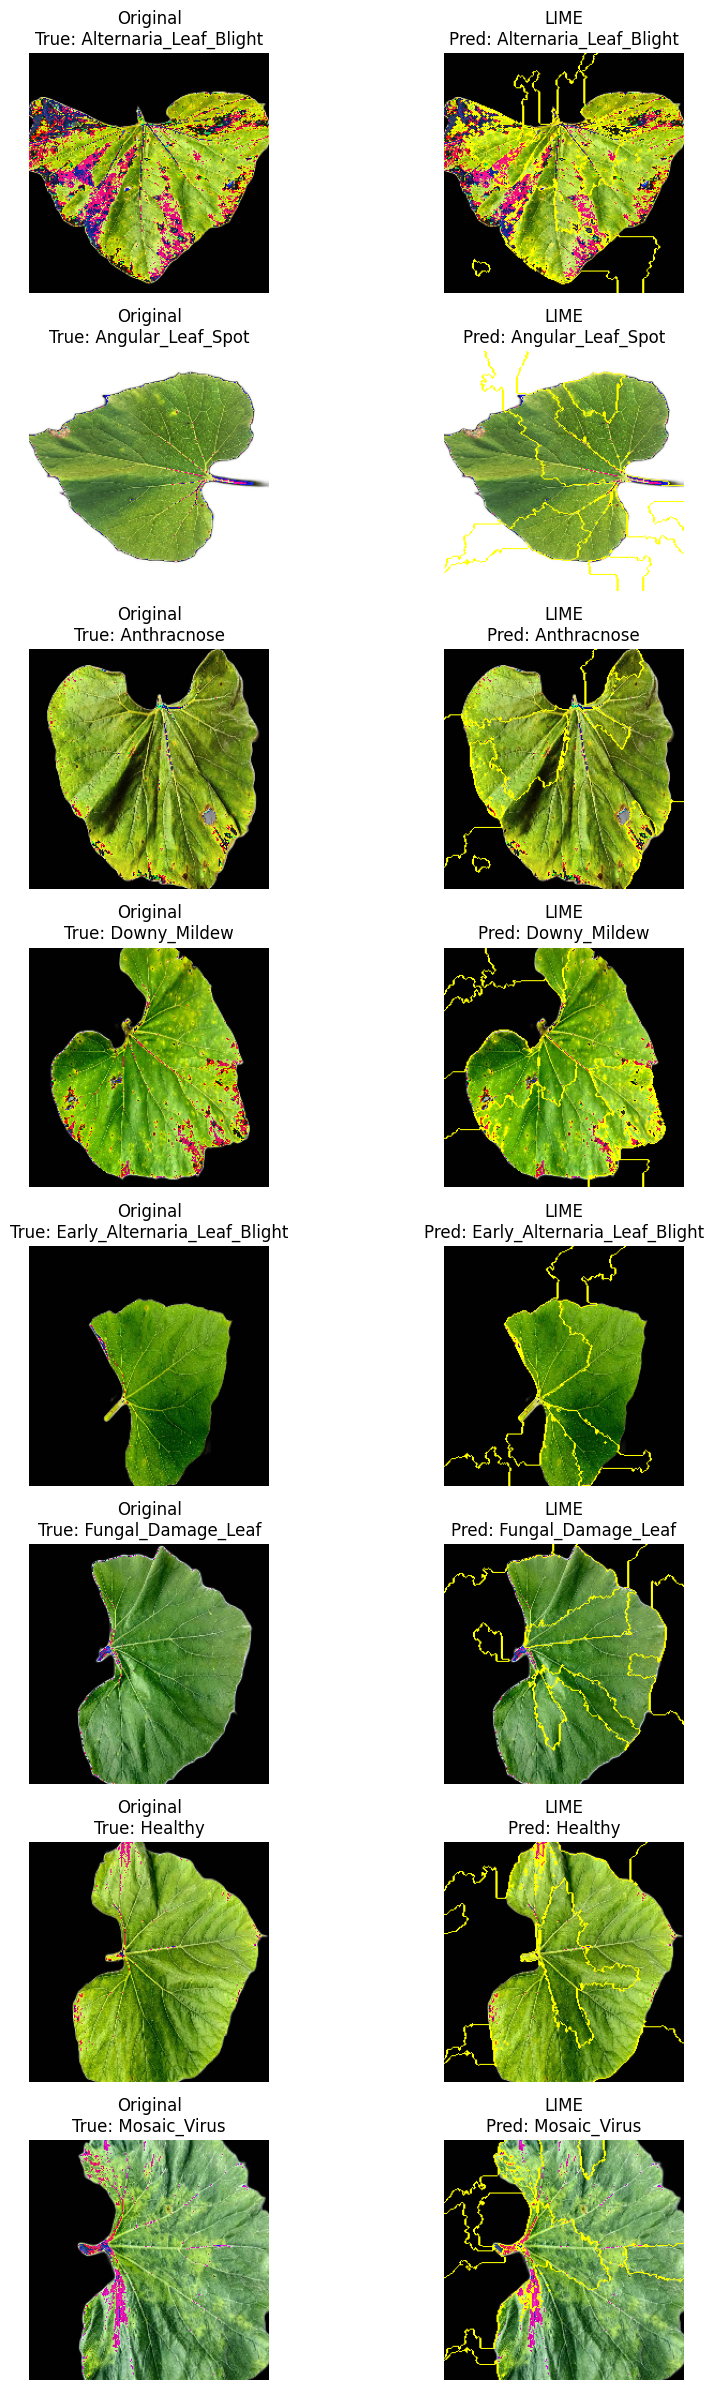

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
import tensorflow as tf

# Step 1: Wrap your test dataset to provide 3 identical inputs per sample
def prepare_test_for_ensemble(ds):
    return ds.map(lambda x, y: ((x, x, x), y))

test_ds_ensemble = prepare_test_for_ensemble(test_ds)

# Step 2: Define a prediction function for LIME
def ensemble_predict(images):
    inputs = [images, images, images]  # replicate input for ensemble
    preds = ensemble_model.predict(inputs)
    return preds

# Step 3: Collect one image per class
class_images = {}
for (batch_x1, batch_x2, batch_x3), batch_y in test_ds_ensemble.unbatch():
    label = np.argmax(batch_y.numpy())
    if label not in class_images:
        class_images[label] = (batch_x1.numpy(), batch_y.numpy())
    if len(class_images) == NUM_CLASSES:
        break

# Step 4: Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()

# Step 5: Run LIME on each class image
fig, axes = plt.subplots(nrows=NUM_CLASSES, ncols=2, figsize=(10, NUM_CLASSES * 3))

for i in range(NUM_CLASSES):
    img, label_onehot = class_images[i]
    true_label = np.argmax(label_onehot)

    # Prepare image
    img_uint8 = (img * 255).astype(np.uint8)

    # LIME explanation
    explanation = explainer.explain_instance(
        img_uint8,
        classifier_fn=ensemble_predict,
        top_labels=NUM_CLASSES,
        hide_color=0,
        num_samples=1000
    )

    predicted_label = np.argmax(ensemble_predict(img[np.newaxis, ...]))

    # Get explanation
    temp, mask = explanation.get_image_and_mask(
        label=predicted_label,
        positive_only=True,
        hide_rest=False,
        num_features=10,
        min_weight=0.0
    )

    # Plot
    axes[i, 0].imshow(img_uint8)
    axes[i, 0].set_title(f"Original\nTrue: {class_names[true_label]}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mark_boundaries(temp, mask))
    axes[i, 1].set_title(f"LIME\nPred: {class_names[predicted_label]}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


In [33]:
pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.4/996.4 kB 27.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]
Note: you may need to restart the kernel to use updated packages.


2025-08-19 08:25:08.445828: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-19 08:25:08.561358: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-19 08:25:09.589458: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-19 08:25:12.527164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-08-19 08:25:12.634571: E external/local_xla/xla/stream_

Showing SHAP heatmaps for all 1 classes


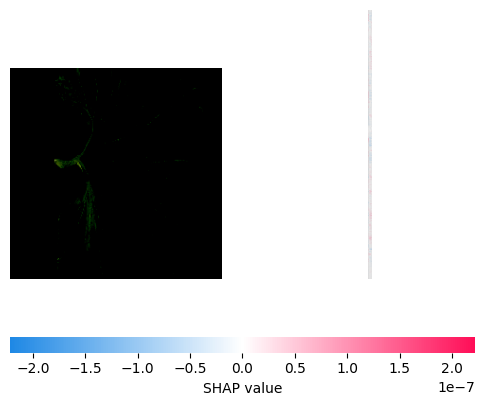

True Label: Mosaic_Virus


In [34]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ---------------------------
# Step 1: Prepare test dataset for ensemble input
# ---------------------------
def prepare_test_for_ensemble(ds):
    return ds.map(lambda x, y: ((x, x, x), y))

test_ds_ensemble = prepare_test_for_ensemble(test_ds)

# ---------------------------
# Step 2: Extract background images for SHAP
# ---------------------------
background_images = []
for (x1, _, _), _ in test_ds_ensemble.take(10):  # take more batches for better background
    background_images.append(x1.numpy())
background_images = np.concatenate(background_images, axis=0)
background_images = background_images[:100]  # limit to 100 samples

# ---------------------------
# Step 3: Define ensemble prediction function
# ---------------------------
def ensemble_predict_for_shap(images):
    inputs = [images, images, images]
    preds = ensemble_model.predict(inputs)
    return preds

# ---------------------------
# Step 4: Create SHAP explainer
# ---------------------------
explainer = shap.GradientExplainer(ensemble_model, [background_images] * 3)

# ---------------------------
# Step 5: Select a test image for explanation
# ---------------------------
for (batch_x1, batch_x2, batch_x3), batch_y in test_ds_ensemble.take(1):
    test_images = batch_x1[0:1].numpy()  # shape (1, H, W, C)
    true_label = np.argmax(batch_y[0].numpy())
    break

# ---------------------------
# Step 6: Compute SHAP values
# ---------------------------
shap_values_raw = explainer.shap_values([test_images, test_images, test_images])  # 3 inputs → 7 class outputs

# ---------------------------
# Step 7: Aggregate SHAP values from the 3 inputs (ensemble)
# ---------------------------
# shap_values_raw shape: [3][7][1, H, W, C] => convert to [7][1, H, W, C]
shap_values = []
num_classes = len(shap_values_raw[0])
for class_idx in range(num_classes):
    sum_shap = np.sum([
        shap_values_raw[0][class_idx],
        shap_values_raw[1][class_idx],
        shap_values_raw[2][class_idx]
    ], axis=0)
    shap_values.append(sum_shap)

# ---------------------------
# Step 8: Visualize SHAP image explanations for all classes
# ---------------------------
print(f"Showing SHAP heatmaps for all {num_classes} classes")
shap.image_plot(shap_values, test_images)

print(f"True Label: {class_names[true_label]}")


2025-07-29 07:49:09.431426: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-29 07:49:09.585074: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-29 07:49:10.617050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-29 07:49:10.769645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-29 07:49:11.923984: E external/local_xla/xla/stream_

IndexError: list index out of range

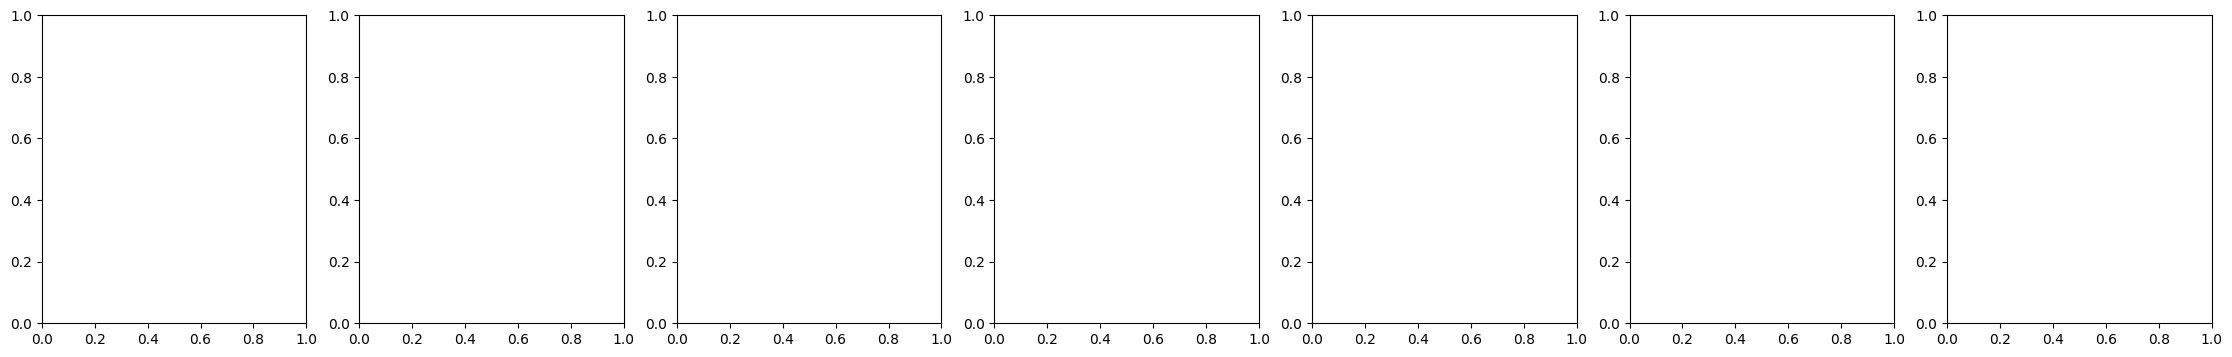

In [30]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Step 1: Prepare test dataset with 3 identical inputs (if not already done)
def prepare_test_for_ensemble(ds):
    return ds.map(lambda x, y: ((x, x, x), y))

test_ds_ensemble = prepare_test_for_ensemble(test_ds)

# Step 2: Extract representative background images from x1 input
background_images = []
for (x1, _, _), _ in test_ds_ensemble.unbatch().take(100):
    background_images.append(x1.numpy())
background_images = np.array(background_images)

# Step 3: Define prediction wrapper for SHAP
def ensemble_predict_for_shap(images):
    # Replicate input across all 3 ensemble branches
    input_batch = [images, images, images]
    return ensemble_model.predict(input_batch)

# Step 4: Initialize SHAP explainer
explainer = shap.GradientExplainer(ensemble_model, [background_images]*3)

# Step 5: Show SHAP explanations for 7 classes using one test image
for (x1_batch, _, _), y_batch in test_ds_ensemble.take(1):
    test_image = x1_batch[0:1].numpy()   # Shape: (1, 224, 224, 3)
    true_label = np.argmax(y_batch[0].numpy())
    break

# Step 6: Compute SHAP values for the test image
shap_values = explainer.shap_values([test_image]*3)

# Step 7: Visualize SHAP for all classes
num_classes = len(shap_values)
fig, axes = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))

for i in range(num_classes):
    # shap_values[i][0] shape: (224, 224, 3)
    heatmap = shap_values[i][0]
    img_to_plot = test_image[0]  # Shape: (224, 224, 3)

    axes[i].imshow((img_to_plot * 0.5 + 0.5))  # Normalize to [0,1] range
    axes[i].imshow(heatmap, cmap='jet', alpha=0.5)
    axes[i].set_title(f"Class: {class_names[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"True Label: {class_names[true_label]}")


In [29]:
import numpy as np
from sklearn.model_selection import KFold

# Step 1: Extract all images and labels from tf.data.Dataset (e.g., train_ds_full)
images = []
labels = []

for img_batch, label_batch in train_ds_full:  # <-- use your dataset name here
    images.extend(img_batch.numpy())
    labels.extend(label_batch.numpy())

X = np.array(images)
y = np.array(labels)

# Step 2: Optional — convert one-hot labels to categorical if needed
if y.ndim == 2:  # one-hot encoded
    y = np.argmax(y, axis=1)

# Now X and y are ready for K-Fold
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


NameError: name 'train_ds_full' is not defined

In [ ]:
from sklearn.preprocessing import label_binarize

# Binarize y_true and y_pred for ROC
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
y_pred_bin = y_pred_probs  # Already probabilities

# Compute macro ROC AUC
roc_auc = roc_auc_score(y_true_bin, y_pred_bin, average="macro")
print(f"Macro-average ROC AUC: {roc_auc:.3f}")


In [ ]:
plt.figure(figsize=(8,4))
plt.plot(val_acc_per_fold, label='Validation Accuracy')
plt.plot(val_loss_per_fold, label='Validation Loss')
plt.title('Validation Accuracy and Loss across Folds')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()
